<span style="font-size:20px;"><b>Construccion de modelo Machine Learning</b></span>
<br>
<b>Fecha:</b> 17/08/2025
<br>
<b>Autor:</b> Lesly Alejandra Escobar Aguilar

<span style="font-size:20px;"><b>Librerias</b></span>

In [14]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt 
import seaborn as sns
import matplotlib
from datetime import date
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

<span style="font-size:20px;"><b>Análisis y Clustering</b></span>
<br>

In [3]:
#importacion del archivo csv
df = pd.read_csv('marketing_campaign.csv', delimiter=';', on_bad_lines='skip')

#Elimina espacios de las columnas
df.columns = df.columns.str.strip()

pd.set_option('display.max_rows', None) #Muesta todas las filas
pd.set_option('display.max_columns', None) #Muestra todas las columnas 

In [4]:
# Ordenamos por ID de menor a mayor
df = df.sort_values(by='ID', ascending=True)

# Eliminar espacios en los nombres de columnas
df.columns = df.columns.str.strip()

# Eliminar duplicados si los hubiera
df = df.drop_duplicates()

# Vista previa
pd.set_option('display.max_rows', 1000)
df.head(1000)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,0,1985,Graduation,Married,70951.0,0,0,4/5/2013,66,239,10,554,254,87,54,1,3,4,9,1,0,0,0,0,0,0,3,11,0
1,1,1961,Graduation,Single,57091.0,0,0,15/6/2014,0,464,5,64,7,0,37,1,7,3,7,5,0,0,0,0,1,0,3,11,1
2,9,1975,Master,Single,46098.0,1,1,18/8/2012,86,57,0,27,0,0,36,4,3,2,2,8,0,0,0,0,0,0,3,11,0
3,13,1947,PhD,Widow,25358.0,0,1,22/7/2013,57,19,0,5,0,0,8,2,1,0,3,6,0,0,0,0,0,0,3,11,0
4,17,1971,PhD,Married,60491.0,0,1,6/9/2013,81,637,47,237,12,19,76,4,6,11,7,5,0,0,0,0,0,0,3,11,0
5,20,1965,2n Cycle,Married,46891.0,0,1,1/9/2013,91,43,12,23,29,15,61,1,2,1,4,4,0,0,0,0,0,0,3,11,0
6,22,1976,Graduation,Divorced,46310.0,1,0,3/12/2012,99,185,2,88,15,5,14,2,6,1,5,8,0,0,0,0,0,0,3,11,0
7,24,1960,Master,Together,17144.0,1,1,15/2/2014,96,18,2,19,0,2,6,5,3,0,4,7,0,0,0,0,0,0,3,11,0
8,25,1958,Graduation,Married,65148.0,0,1,16/11/2012,9,460,35,422,33,12,153,2,6,6,7,4,0,0,0,0,0,0,3,11,0
9,35,1987,Graduation,Married,25545.0,1,0,8/9/2012,35,32,1,64,16,12,85,3,2,2,3,6,0,0,0,0,0,0,3,11,1


<span style="font-size:20px;"><b>Identificicacion de tipos de variables y manejo de datos faltantes</b></span>
<br>

In [5]:
#Seleccion de variables
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()

print("Columnas numéricas:", numericas)
print("Columnas categóricas:", categoricas)

#Primeras 1000 columnas
df_data = df.sample(1000, random_state=42)

df_data = df_data.dropna()

#Datos faltantes
# Numéricas → media
num_imputer = SimpleImputer(strategy='mean')
df_data[numericas] = num_imputer.fit_transform(df_data[numericas])

# Categóricas → moda
cat_imputer = SimpleImputer(strategy='most_frequent')
df_data[categoricas] = cat_imputer.fit_transform(df_data[categoricas])

Columnas numéricas: ['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']
Columnas categóricas: ['Education', 'Marital_Status', 'Dt_Customer']


<span style="font-size:20px;"><b>Preprocesamiento y Kmeans</b></span>
<br>

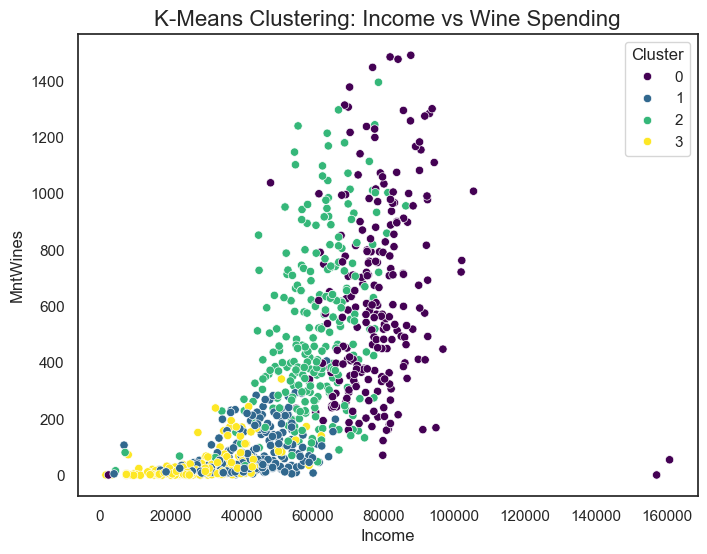

In [12]:
#Procesamiento y Kmeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numericas),
        ('cat', OneHotEncoder(), categoricas)
    ]
)

# Definir K-Means
kmeans_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('kmeans', KMeans(n_clusters=4, random_state=42))
])

# Ajustar modelo
kmeans_pipeline.fit(df_data)
df_data['Cluster'] = kmeans_pipeline.named_steps['kmeans'].labels_

#Cluster
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_data, x='Income', y='MntWines', hue='Cluster', palette='viridis')
plt.title("K-Means Clustering: Income vs Wine Spending", fontsize=16)
plt.show()


<span style="font-size:20px;"><b>Análisis de Gastos</b></span>
<br>
<ul>
    <li>Educacion vs Gastos</li>
    <li>Rstado civil vs Gastos</li>
    <li>Cluster vs Gastos</li>
</ul>

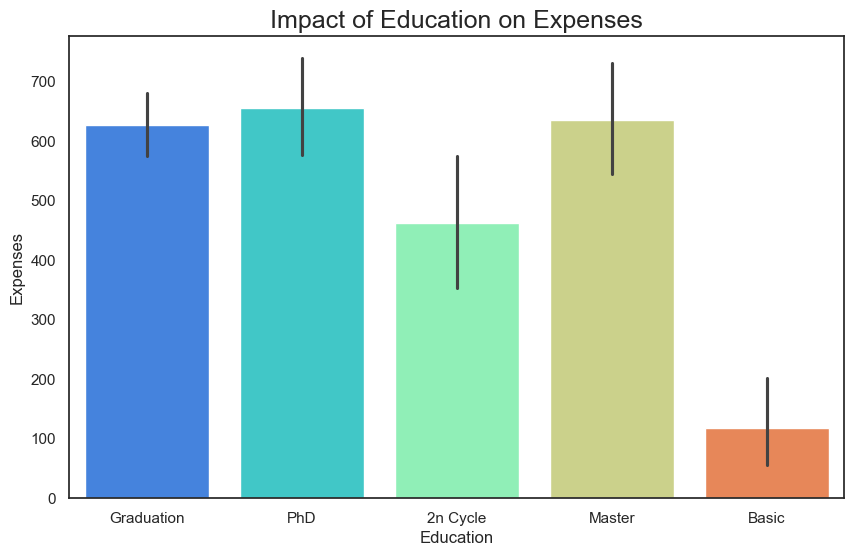

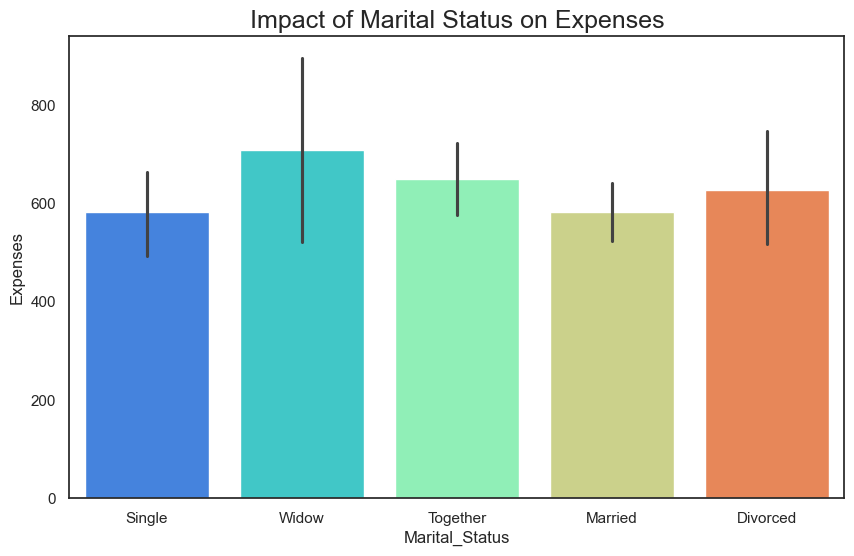

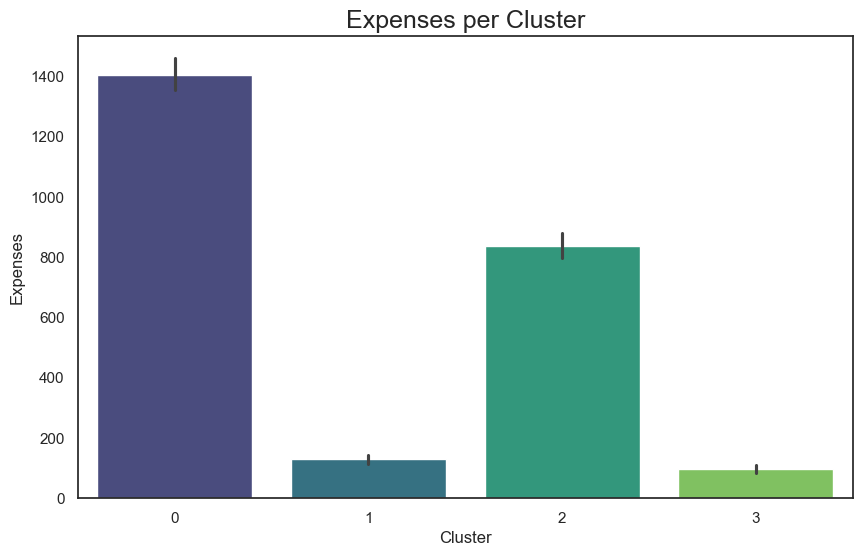

In [13]:
# Crear columna de gastos totales
df_data['Expenses'] = (df_data['MntWines'] + df_data['MntFruits'] + 
                         df_data['MntMeatProducts'] + df_data['MntFishProducts'] + 
                         df_data['MntSweetProducts'] + df_data['MntGoldProds'])
# Education vs Expenses
pd.crosstab(df_data['Education'], df_data['Expenses'], margins=True).style.background_gradient(cmap='Greys')
sns.set_theme(style="white")
plt.figure(figsize=(10,6))
plt.title("Impact of Education on Expenses", fontsize=18)
ax = sns.barplot(x="Education", y="Expenses", data=df_data, palette="rainbow")
plt.show()

#Marital_Status vs Expenses
pd.crosstab(df_data['Marital_Status'], df_data['Expenses'], margins=True).style.background_gradient(cmap='Greys')

plt.figure(figsize=(10,6))
sns.barplot(x="Marital_Status", y="Expenses", data=df_data, palette="rainbow")
plt.title("Impact of Marital Status on Expenses", fontsize=18)
plt.show()

#Cluster vs Expenses
plt.figure(figsize=(10,6))
sns.barplot(x="Cluster", y="Expenses", data=df_data, palette="viridis")
plt.title("Expenses per Cluster", fontsize=18)
plt.show()



<span style="font-size:20px;"><b>Conclusiones</b></span>
<br>

<ul>
    <li>El modelo permite identificar y agrupar a cuatro posibles clientes en cuatro patrones distintos de gastos</li>
    <li>La variable Expenses reune la suma de gastos de algunos productos como: vinos, frutas, carne, pescado, dulces y oro</li>
    <li>No siempre los ingresos altos implican que el cliente gaste en vino, en algunos casos existen clientes con ingresos medios y alta gasto en vinos</li>
    <li>Clientes con educacion superior tienden a gastar mas</li>
    <li>Las personas que se encuentran con estado civil viudo tienden a gastar un poco mas identificandolas como clientes valiosos</li>
</ul>

<span style="font-size:12px;"><b>Cluster identificados</b></span>
<ul>
    <li>Cluster 0: clientes premium</li>
    <li>Cluster 2: clientes regulares</li>
    <li>Cluster 1 y 3: clientes de baja presencia</li>
</ul>